In [3]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
import pyopencl as cl
from pathlib import Path
import json
from scipy.fft import fft, ifft, fftfreq

%matplotlib inline


$$\bf{Notes}$$

$$
\begin{align}
&\text{-Plot all the rois on one plot. Try changing the center of the masks, binsize, numRings, numSlices and see if the results are consistent} \\
&\text{-Vegard's law} \\
&\text{|F(Q,t)| = aexp(-(t/$\tau_f$)^$\beta$) + (1-a)exp(-(t/$\tau_s$)^$\beta$)}\\ 
&\text{For APS data, use the 2D Gaussian for STD extraction. 1D doesn't seem as great}
\end{align}
$$

# User Defined Variables 

$$
|F(\mathbf{q}, t)| = e^{\left(-t/\tau(\mathbf{q})\right)^{\beta(\mathbf{q})}}
$$


$$
g_{2}(\mathbf{q},t) = 1+A|F(\mathbf{q}, t)|^2
$$

In [4]:
### User Defined
### This should be the only thing that needs to defined
CONFIG_FILE_NAME = "config_IPA_NBH_A4_data_113025.json" #"config_NPS_2_data_090825.json" #"config_B10_2_A7_data_071525.json"

### Scan In Config You Want to PreProcess ### 
Scan = 73

# Analysis Parameters

In [35]:
#Crop Size
#number of standard deviations from peak
Xv = 5 
Xh = 5

#Binning Parameters
#Number of pixels in every direction to bin
#A bin size of 1 does not bin
binSize = 1

timeBatch = -1 #seconds
startTime = 0 #seconds

stability = False 

Detrend = False

#Mask Parameters
New_Mask = True
Tilted_Mask = True
maskSize = 25.0 #Standard deviations
numRings = 3  # Number of elliptical rings
numSlices = 6 # Number slices, should be even
tol = 0.1 # Percentage tolerance for converging to ring partition
res = float(0.0001) # Resolution for ring size increments

#XPCS fitting parameters
a = 0.4
tt1 = 50
tt2 = 5000
b1 = 2
b2 = 1.0
trunc = -3 # Cut last few points from fit
Double_Exp = False

#Constants 
notzero = 1.0**(-12)

# File Paths

In [6]:
### Open Config File ###
# Define the path to the configuration file
config_file = Path('/Users/eriklamb/Documents/Python/Projects/XPCS/configs/'+CONFIG_FILE_NAME)

# Open and load the JSON configuration file
with open(config_file, "r") as file:
    config = json.load(file)

### Load Work Paths ###
BASE_DIR       = Path(config.get("Base"))
dataset_path   = Path(config.get(f"{Scan}"))
work_path      = BASE_DIR / dataset_path 
processed_path = work_path / Path(config.get("Processed")) / Path(config.get(f"{Scan}_processed"))

                     

### Import Beamline Parameters ###
### Not user defined ###
Beamline      = config.get("Beamline") #P10 or 8IDE
Geometry      = config.get("Geometry") #Horizontal or Vertical
Compound      = config.get("Compound")
Particle      = config.get("Particle") #2,3, A7


#Temperature Handled Differently Depending on Source 
if 'B10' in Compound:
    Temperature = float(str(dataset_path)[21:27])/1000 #Temperature in Kelvin
if 'NPS' in Compound:
    Temperature = float(config.get(f"{Scan}_temperature")) #Temperature in Kelvin
    
    

#Check that path exists
if work_path.exists():
    print(f'Directory found: {work_path}')
else:
    print(f'Directory not found: {work_path}')

#Load File Names
file_list = np.sort(os.listdir(work_path)).tolist()

#Remove first element if it's DS_Store
if file_list[0] == '.DS_Store':
    file_list.remove(file_list[0])

#Removes strange file that occurs if you edit batchinfo
if file_list[0][0:2] == '._':
    file_list.remove(file_list[0])

print('Contains:') 
for f in file_list:
    print(f)

Directory found: /Users/eriklamb/Desktop/shpyrko202510/A073_IPA_NBH_1_att0100_260K_001
Contains:
A073_IPA_NBH_1_att0100_260K_001.h5
A073_IPA_NBH_1_att0100_260K_001_0001-4800.batchinfo
A073_IPA_NBH_1_att0100_260K_001_metadata.hdf
processed


# Load Data

In [7]:
#Set the path to the processed file 
#processed = processed_path+f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}.h5'

#Check that the processed file exists
if not os.path.exists(processed_path):
    print(f"File '{processed_path}' does not exist! Please create it in pre_processing.")

#Load file
with h5py.File(processed_path, 'r') as DATA:
    
    pixelSize    = DATA['experimental_parameters/pixel_size'][:][0]
    frameSpacing = DATA['experimental_parameters/frame_spacing'][:][0]
    nFrames      = DATA['experimental_parameters/nFrames'][:][0]
    tilt         = DATA['pre_processing/angular_tilt'][:][0]
    Qx           = DATA['pre_processing/Qx'][:]
    Qy           = DATA['pre_processing/Qy'][:]
    hSig         = DATA['pre_processing/hSig'][:][0]
    vSig         = DATA['pre_processing/vSig'][:][0]
    
    if timeBatch == -1:
        timeBatch = nFrames*frameSpacing
        
    POPT         = DATA['gaussian_fitting/POPT'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:]
    PCOV         = DATA['gaussian_fitting/PCOV'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:]
    popt2d       = DATA['gaussian_fitting/popt'][:]

    
    #Take timeChunk of data. Not whole scan
    det          = DATA['data/det'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:,:]
    det_corr     = DATA['data/det_corr'][:][int(startTime//frameSpacing):int(startTime//frameSpacing)+int(timeBatch//frameSpacing),:,:]

    

# Check Peak Stability

In [8]:
nframes = det.shape[0]

#Store fit results
POPTX = np.zeros((nframes,4))
POPTY = np.zeros((nframes,4))

#Loop through each image
for t,im in enumerate(det):
    poptx,popty,_,_ = integrated_gaussian(im,stdy=50,stdx=10)
    POPTX[t,:] += poptx
    POPTY[t,:] += popty

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

In [6]:
Mux = POPTX[:,1]
Muy = POPTY[:,1]
SigX = (POPTX[:,2]-np.mean(POPTX[:,2]))/np.mean(POPTX[:,2])
SigY = (POPTY[:,2]-np.mean(POPTY[:,2]))/np.mean(POPTY[:,2])
freqs = fftfreq(nframes,frameSpacing)[:nframes//2]
ftMux = np.abs(fft(POPTX[:,1])[:nframes//2])
ftMuy = np.abs(fft(POPTY[:,1])[:nframes//2])
ftSigX = np.abs(fft(POPTX[:,2])[:nframes//2])
ftSigY = np.abs(fft(POPTY[:,2])[:nframes//2])
time = frameSpacing*np.arange(nframes)

fig,ax = plt.subplots(2,2)
fig.set_size_inches(12, 4)

ax2 = ax[0,0].twinx()
ax[0,0].plot(frameSpacing*np.arange(nframes),Mux,'b')
ax2.plot(frameSpacing*np.arange(nframes),Muy,'r')
ax[0,0].set_ylabel('$\\mu_{x}$',fontsize=18,color='blue')
ax2.set_ylabel('$\\mu_{y}$',fontsize=18,color='red')




ax4 = ax[0,1].twinx()
ax[0,1].semilogy(freqs,ftMux,'b')
ax4.semilogy(freqs,ftMuy,'r')
ax[0,1].set_ylabel('$\\widehat{f}(\\mu_{x})$',fontsize=18,color='blue')
ax4.set_ylabel('$\\widehat{f}(\\mu_{y})$',fontsize=18,color='red')


ax[0,0].set_xlabel('Time (s)')
ax[0,1].set_xlabel('Frequency (Hz)')


ax6 = ax[1,0].twinx()
ax[1,0].plot(frameSpacing*np.arange(nframes),SigX,'b')
ax6.plot(frameSpacing*np.arange(nframes),SigY,'r')
ax[1,0].set_ylabel('$\\sigma_{x}$',fontsize=18,color='blue')
ax6.set_ylabel('$\\sigma_{y}$',fontsize=18,color='red')


ax8 = ax[1,1].twinx()
ax[1,1].semilogy(freqs,ftSigX,'b')
ax8.semilogy(freqs,ftSigX,'r')
ax[1,1].set_ylabel('$\\widehat{f}(\\sigma_{x})$',fontsize=18,color='blue')
ax8.set_ylabel('$\\widehat{f}(\\sigma_{y})$',fontsize=18,color='red')


ax[1,0].set_xlabel('Time (s)')
ax[1,1].set_xlabel('Frequency (Hz)')

plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

#DO CENTER OF MASS, not Gaussian

NameError: name 'POPTX' is not defined

# Mask Extraction

In [7]:
if not New_Mask:
    with h5py.File(mask_path, 'r') as DATA:
        masks = DATA['XPCS/Mask'][:]
        ringWidths = DATA['XPCS/ringWidths'][:]
        
    #For Plotting. Change -1s to 0s
    masks_plot = np.copy(masks)
    #masks_plot[masks_plot==-1] = 0

    for i in range(masks_plot.shape[0]):
        masks_plot[i,:,:] = (i+1)*masks_plot[i,:,:]
        
    #Sum of the masks for a single mask image
    mask_sum = np.sum(masks_plot,axis=0)
    
    
    fig, ax = plt.subplots()
    ax.imshow(mask_sum,'nipy_spectral',clim=(1,numRings*numSlices+3.5))

# Bin Cropped Data and Q-Maps and Plot

In [7]:
### Binning Section. Bin images as well as the Q maps ###
detBinned,_ = binning(det,binSize,pixelSize,'sum')
det_corr,_ = binning(det_corr,binSize,pixelSize,'sum')

### Bin the Q-Map according to the same binning as the detector ###
Qx,_ = binning(Qx,binSize,mode='mean')
Qy,_ = binning(Qy,binSize,mode='mean')

    
### Plotting ###
import matplotlib.pyplot as plt
%matplotlib notebook

fig, axs = plt.subplots(1, 2, figsize=(8, 4))
#print(det.shape)

axs[0].imshow(np.sum(det[0:1,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35))
axs[0].set_title('Unbinned')

axs[1].imshow(np.sum(detBinned[0:1,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35*binSize))
axs[1].set_title('{}x{} Binned'.format(binSize,binSize))

#axs.axes.xaxis.set_visible(False)
#axs.axes.yaxis.set_visible(False)

#Det det to binned copy
det = np.copy(detBinned)


<IPython.core.display.Javascript object>

In [8]:
fig, ax  = plt.subplots(1,2)

ax[0].imshow(det_corr[0,:,:]+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=5))
ax[1].plot(np.sum(det[0,:,:],axis=1))
plt.show()

<IPython.core.display.Javascript object>

# Create Elliptical Mask

In [36]:
mx0,my0 = com(np.mean(det[:,:,:],axis=0))
#mx0 = 438.0
#my0 = 854.0
#,my0 = 420//binSize,780//binSize
#mx0 = mx0-0.25*hSig

if New_Mask:
    
    if not Tilted_Mask:
        tilt = 0
        
    #hSig = np.mean(POPT[:,3])
    #VSig = np.mean(POPT[:,4])

    #Create Elliptical Masks. Non-masked regions are -1
    masks,ringWidths = const_int_mask(det,hSig/binSize,vSig/binSize,mx0-0.25*hSig,my0,maskSize,numRings,numSlices,-tilt,tol,res) #Create the masks of equal intensity

    #For Plotting. Change -1s to 0s
    masks_plot = np.copy(masks)
    #masks_plot[masks_plot==-1] = 0

    for i in range(masks_plot.shape[0]):
        masks_plot[i,:,:] = (i+1)*masks_plot[i,:,:]

    #Sum of the masks for a single mask image
    mask_sum = np.sum(masks_plot,axis=0)
    
#if New_Mask == False:
#    masks,_ = binning(mask,binSize,'mean')


#Create the displacement in Q from Q0 for each mask
dQ = np.zeros(masks.shape[0])

#Find the center of the peak
#Qx0 = Qx[Qx.shape[0]//2,Qx.shape[1]//2]
#Qy0 = Qy[Qy.shape[0]//2,Qy.shape[1]//2]

Qx0 = Qx[int(my0),int(mx0)]
Qy0 = Qy[int(my0),int(mx0)]

#Calculate the mean displacement from the center for each ROI
for i in range(masks.shape[0]):
    dQ[i] = np.mean(np.sqrt((Qx-Qx0)**2+(Qy-Qy0)**2)[masks[i,:,:]==1])    

0.30423663794686306
0.30586762590192546
0.3000071188946593
[1.4263 2.0648 4.8638]


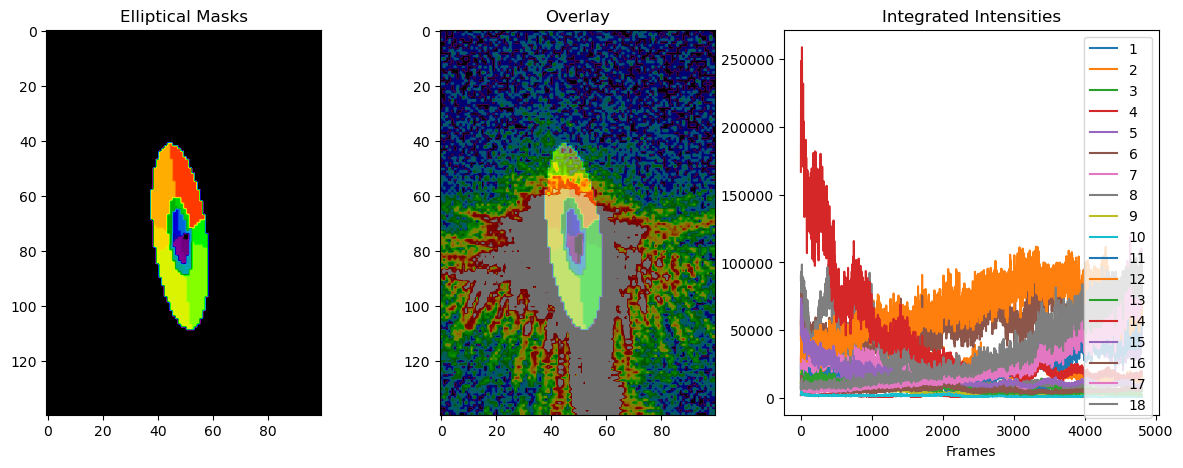

In [37]:
### Plotting ###
import matplotlib.pyplot as plt
%matplotlib inline

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
#print(det.shape)

#Plot the Masks alone, with labels
axs[0].imshow(mask_sum,'nipy_spectral',clim=(1,numRings*numSlices+3.5))
axs[0].set_title('Elliptical Masks')

#Plot the masks overlayed on the detector image
# Display the first image of mask sum
axs[1].imshow(mask_sum-1, cmap='nipy_spectral',clim =(1,numRings*numSlices+3), alpha=1)
# Overlay the second image with a 'plasma' color scale and some transparency
axs[1].imshow(np.sum(det[0:5,:,:],axis=0)+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=35*binSize),alpha=0.55)
axs[1].set_title('Overlay')


#Plot the integrated intensity of each mask region
#i=0
for i,m in enumerate(masks): 
    axs[2].plot(np.sum(det[:,m==1],axis=1),label='{}'.format(i+1))
    #i+=1
axs[2].set_title('Integrated Intensities')
axs[2].set_xlabel('Frames')
axs[2].legend()

plt.subplots_adjust(wspace=0.05, hspace=0.4)
plt.show()

# Detrending

<IPython.core.display.Javascript object>


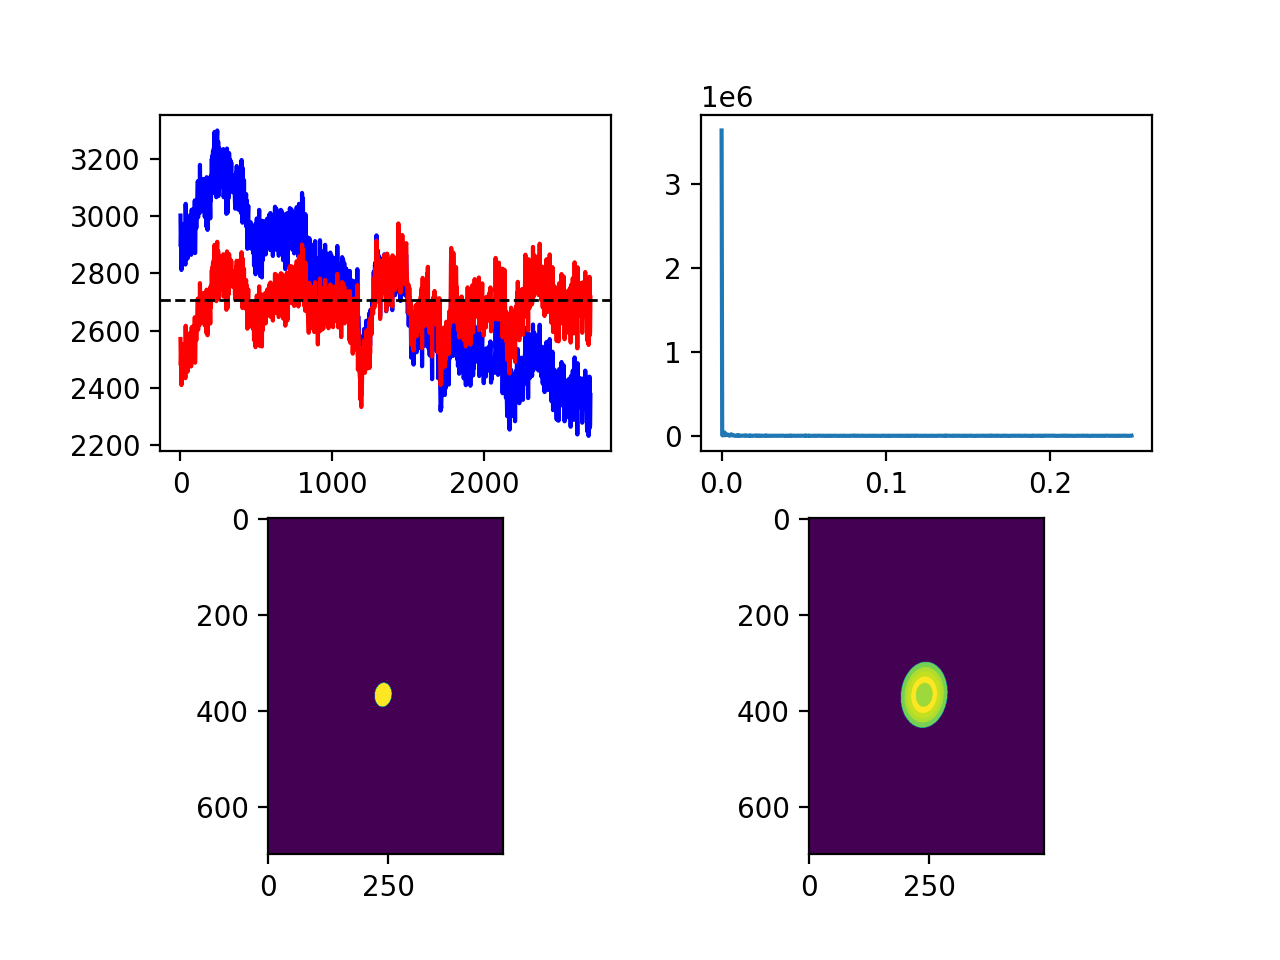

<IPython.core.display.Javascript object>


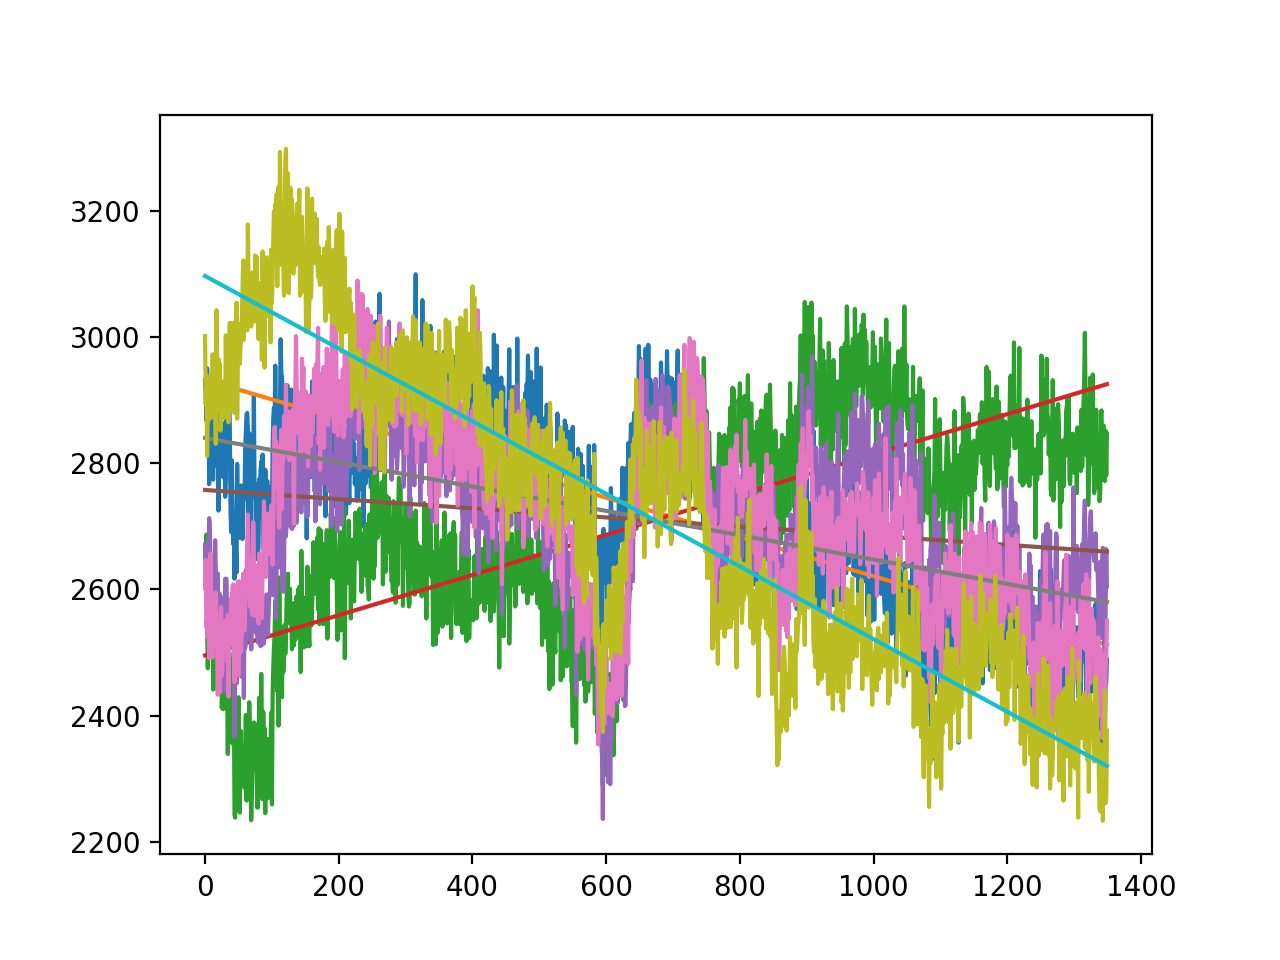

/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_76470/2596738371.py:23: RuntimeWarning: overflow encountered in scalar subtract
  popt,pcov = curve_fit(detrend,time,intensity,p0=[(intensity[-1]-intensity[0])/time[-1],intensity[0]])


In [13]:

fig,ax = plt.subplots(2,2)

def detrend(t,a,b):
    return b+a*t
"""""""""
for i,m in enumerate(masks): 
    intensity = np.sum(det_dt[:,m==1],axis=1)
    popt,pcov = curve_fit(detrend,time,intensity)
    #dt_int = 1+(np.mean(intensity)-detrend(time,*popt))/np.mean(intensity)
    mean_int = np.mean(intensity)
    print(mean_int)
    det_dt[:,m==1] = det_dt[:,m==1]-detrend(time,*popt)[:,np.newaxis] + mean_int
"""""""""

dt = np.zeros((time.shape[0],masks.shape[1],masks.shape[2]))
fig2,ax2=plt.subplots()

#for i,m in enumerate(masks): 
#    ax2.plot(np.sum(det[:,m==1],axis=1),label='{}'.format(i+1))
for i,m in enumerate(masks):
    intensity = np.sum(det[:,m==1],axis=1)

    popt,pcov = curve_fit(detrend,time,intensity,p0=[(intensity[-1]-intensity[0])/time[-1],intensity[0]])

    ax2.plot(intensity)
    ax2.plot(detrend(time,*popt))
    dt_int = (np.mean(intensity)-detrend(time,*popt))/np.mean(intensity)+1

    dt += dt_int[:,np.newaxis,np.newaxis] * m

ax[0,0].plot(time,intensity,'b')
ax[0,0].plot(time,dt_int*intensity,'r')
ax[0,0].axhline(y=np.mean(intensity), color='k', linestyle='--', linewidth=1)
ax[0,1].plot(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(dt_int*intensity)[:nframes//2]))

ax[1,0].imshow(masks[0,:,:])
ax[1,1].imshow(dt[0,:,:])

if Detrend:
    det = det.astype(np.float64)
    det_corr = det_corr.astype(np.float64)
    det *= dt
    
    det_corr *= dt

# Per Pixel Intensity

4800


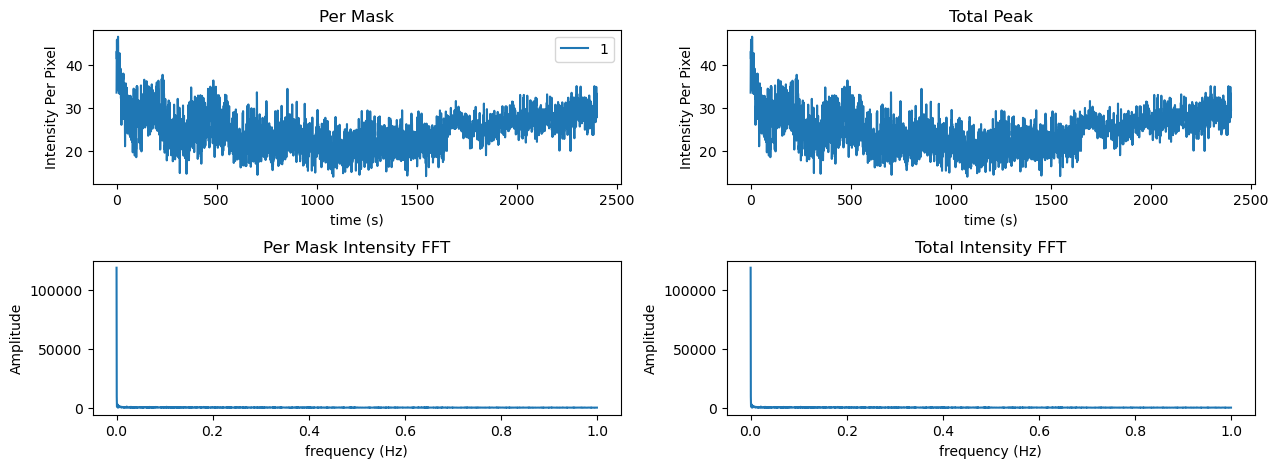

In [11]:
perPixelInt = np.zeros((masks.shape[0],det.shape[0]))
perMaskInt = np.zeros((masks.shape[0],det.shape[0]))

maskPix = 0

for i,m in enumerate(masks): 
    maskPix += np.size(m==1)
    perMaskInt[i,:] += np.sum(det[:,m==1],axis=1)
    perPixelInt[i,:] += np.sum(det[:,m==1],axis=1)/np.size(m==1)

print(perPixelInt.shape[1])
fig,ax = plt.subplots(2,2,figsize=(15,5))

time = frameSpacing*np.arange(0,perPixelInt.shape[1],1)
for i,ppi in enumerate(perPixelInt):
    ax[0,0].plot(time,ppi,label='{}'.format(i+1))
    ax[1,0].plot(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(ppi)[:nframes//2]))

ax[0,1].plot(time,np.mean(perPixelInt,axis=0))
ax[1,1].plot(fftfreq(nframes,frameSpacing)[:nframes//2],np.abs(fft(np.sum(perPixelInt,axis=0))[:nframes//2]))


ax[0,1].set_xlabel('time (s)')
ax[0,1].set_ylabel('Intensity Per Pixel')  
ax[0,1].set_title('Total Peak')

ax[0,0].set_xlabel('time (s)')
ax[0,0].set_ylabel('Intensity Per Pixel')
ax[0,0].set_title('Per Mask')
ax[0,0].legend()


ax[1,0].set_xlabel('frequency (Hz)')
ax[1,0].set_ylabel('Amplitude')
ax[1,0].set_title('Per Mask Intensity FFT')

ax[1,1].set_xlabel('frequency (Hz)')
ax[1,1].set_ylabel('Amplitude')
ax[1,1].set_title('Total Intensity FFT')


plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

# Main Loop

In [38]:
#Calculate the G2 autocorrelations for the entire image
mask = np.ones(det_corr.shape[1:])

#Delays per level. Increase for more sampling
dpl = 6

#IF are intensities future, intensities past. Used to normalize g2
sumI,G2,IF,IP,_ = g2calc(det_corr,mask,dpl)

# Calculate Frame Spacing
nframes = det_corr.shape[0]
delay = frameSpacing * finddelays(nframes,dpl,1)

(65,)
(65, 4)


ValueError: array must not contain infs or NaNs

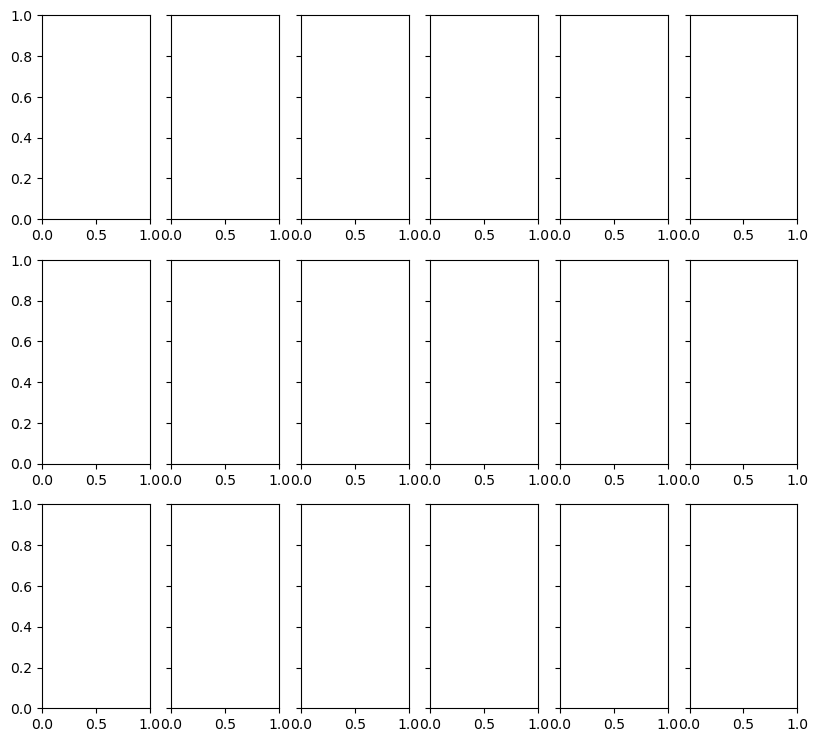

In [39]:
#Used for stuff
if timeBatch == -1:
    timeBatch = nFrames*frameSpacing

#Results Arrays
G2_result = np.zeros((masks.shape[0],delay.shape[1]))
G2_error = np.zeros((masks.shape[0],delay.shape[1]))

colors = np.array(['b','m','g','c','k'])


if not Double_Exp:
    As = np.zeros(masks.shape[0])
    As_err = np.zeros(masks.shape[0])

    betas = np.zeros(masks.shape[0]) #Assumes one betas
    betas_err = np.zeros(masks.shape[0]) #Assumes one betas

    taus = np.zeros(masks.shape[0]) #Assumes one relaxation times
    taus_err = np.zeros(masks.shape[0]) #Assumes relaxation times
    
if Double_Exp:
    As = np.zeros(masks.shape[0])
    As_err = np.zeros(masks.shape[0])
    


    betas = np.zeros((masks.shape[0],2)) #Assumes two betas
    betas_err = np.zeros((masks.shape[0],2)) #Assumes two betas
    taus = np.zeros((masks.shape[0],2)) #Assumes two relaxation times
    taus_err = np.zeros((masks.shape[0],2)) #Assumes two relaxation times
    
aas = np.zeros(masks.shape[0])
aas_err = np.zeros(masks.shape[0])    
    #aas = np.zeros(masks.shape[0])
    #aas_err = np.zeros(masks.shape[0])


if numSlices == 1 and numRings>1:
    fig,axs = plt.subplots(numSlices,numRings,figsize=(30,6), sharey=True) #FFT check
if numRings == 1 and numSlices>1:
    fig,axs = plt.subplots(numRings,numSlices,figsize=(24,6), sharey=True) #FFT check
if numRings > 1 and numSlices>1:
    fig,axs = plt.subplots(numRings,numSlices,figsize=(9.75,9), sharey=True) #FFT check
if numRings == 1 and numSlices == 1:
    fig,axs = plt.subplots(numRings,numSlices,figsize=(9.75,9), sharey=True)

# Indices for plotting
i=0
j=0

#Array for truncating fits
truncs = [trunc]*numRings*numSlices

for mm,m in enumerate(masks):
    
    #Used to single out specific scans for truncating the last few points
    if True:
        if mm in [0]:
            truncs[mm] = -1
        if mm in [1,2,3,4]:
            truncs[mm] = -3
    
    #Used to not truncate
    if truncs[mm] == 0:
        truncs[mm] = G2_result.shape[1]
    
    # Last bit of filtering 
    G2_masked = G2[:,m==1] 
    
    # Removes the detector borders 
    hot_pixel_mask = G2_masked[0,:] < 10**(3) 
    
    """""""""
    # Average and normalize g2s 
    if np.abs(G2_masked.shape[0]-delay.shape[1])==0: 
        last_index = G2_masked.shape[0] 
    if np.abs(G2_masked.shape[0]-delay.shape[1])>0: 
        last_index = -np.abs(G2_masked.shape[0]-delay.shape[1]) 
    """""""""
    
    # Determine usable time/lag index
    if G2_masked.shape[0] == delay.shape[1]:
        last_index = G2_masked.shape[0]
    else:
        last_index = min(G2_masked.shape[0], delay.shape[1])
        
    # Initialize output arrays 
    g2dummy = np.zeros_like(G2_masked) 
    
    # Compute partition normalization factor (avoiding division by zero) 
    part_norm = np.mean(IF[:, m == 1][:, hot_pixel_mask == 1],axis=1) * np.mean(IP[:, m == 1][:, hot_pixel_mask == 1], axis=1) 
    
    print(part_norm.shape) 
    print(G2_masked.shape) 
    
    # Normalize G2 
    g2dummy = np.divide(G2_masked, part_norm[:, np.newaxis], out=np.full_like(G2_masked, np.nan), where=part_norm[:, np.newaxis] != 0) 
    
    # Compute mean and standard error over the mask 
    valid_pixels = hot_pixel_mask == 1 
    
    G2_result[mm, :] += np.mean(g2dummy[:, valid_pixels][:last_index], axis=1) 
    G2_error[mm, :] += np.std(g2dummy[:, valid_pixels][:last_index], axis=1) / np.sqrt(np.sum(valid_pixels))
    
    
    """""""""
    # Last bit of filtering 
    G2_masked = G2[:, m == 1]

    # Mask out detector borders
    hot_pixel_mask = G2_masked[0, :] < 1e3   # boolean mask

    # Determine usable time/lag index
    if G2_masked.shape[0] == delay.shape[1]:
        last_index = G2_masked.shape[0]
    else:
        last_index = min(G2_masked.shape[0], delay.shape[1])

    # Compute normalization factor over valid pixels
    part_norm = (
        np.mean(IF[:, m == 1][:, hot_pixel_mask], axis=1)
        * np.mean(IP[:, m == 1][:, hot_pixel_mask], axis=1)
    )  # shape (T,)

    # Normalize G2 (broadcast part_norm across pixels)
    g2dummy = np.divide(
        G2_masked,
        part_norm[:, None],
        out=np.full_like(G2_masked, np.nan, dtype=float),
        where=part_norm[:, None] != 0,
    )

    # Average g2 over valid pixels and compute standard error
    valid_pixels = hot_pixel_mask
    g2_slice = g2dummy[:last_index, :][:, valid_pixels]

    G2_result[mm, :last_index] += np.mean(g2_slice, axis=1)
    G2_error[mm, :last_index] += np.std(g2_slice, axis=1, ddof=1) / np.sqrt(np.sum(valid_pixels))
    """""""""""


    """""""""
    # Initialize output arrays
    g2dummy = np.zeros_like(G2_masked)

    # Compute partition normalization factor (avoiding division by zero)
    #part_norm = np.mean(IF[:, m == 1][:, hot_pixel_mask == 1],axis=1) * np.mean(IP[:, m == 1][:, hot_pixel_mask == 1], axis=1)
    part_norm = np.mean(IF[:, m == 1],axis=1) * np.mean(IP[:, m == 1], axis=1)
    
    print(part_norm.shape)
    print(G2_masked.shape)
    # Normalize G2
    g2dummy = np.divide(G2_masked, part_norm[:, np.newaxis], out=np.full_like(G2_masked, np.nan), where=part_norm[:, np.newaxis] != 0)

    # Compute mean and standard error over the mask
    valid_pixels = hot_pixel_mask == 1

    G2_result[mm, :] += np.mean(g2dummy[:, valid_pixels][:last_index], axis=1)
    G2_error[mm, :] += np.std(g2dummy[:, valid_pixels][:last_index], axis=1) / np.sqrt(np.sum(valid_pixels))
    """""""""
    


    
    #Fit Each G2(Q)
    #Initial Guesses
    A = np.max(G2_result[mm,:truncs[mm]])-1

    if not Double_Exp:
        lower_bounds = [-np.inf,-np.inf,-np.inf,-np.inf]  # c >= 0
        upper_bounds = [np.inf,np.inf,np.inf,np.inf]

        #Fit the g2s
        if mm == 0:
            popt, pcov = curve_fit(g2_exp, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[A,tt1,b1],bounds=(lower_bounds, upper_bounds))
        else:
            popt, pcov = curve_fit(g2_exp, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[As[mm-1],taus[mm-1],betas[mm-1]],bounds=(lower_bounds, upper_bounds))
            #popt, pcov = curve_fit(g2_exp, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[A,tt1,b1],bounds=(lower_bounds, upper_bounds))
            
        #Update fit results
        As[mm] += popt[0]
        taus[mm] += popt[1]
        betas[mm] += popt[2]

        #Extract errors
        errors = np.sqrt(np.diag(pcov))

        As_err[mm] += errors[0]
        taus_err[mm] += errors[1]
        betas_err[mm] += errors[2]
         
    if Double_Exp:
        lower_bounds = [-np.inf,-np.inf,-np.inf,-np.inf,-np.inf,-np.inf]  # c >= 0
        upper_bounds = [np.inf,np.inf,np.inf,np.inf,np.inf,np.inf]

        #Fit the g2s
        if mm == 0:
            popt, pcov = curve_fit(g2_two_tau, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[A,a,tt1,tt2,b1,b2],bounds=(lower_bounds, upper_bounds))
        else:
            popt, pcov = curve_fit(g2_two_tau, delay[0,:truncs[mm]], G2_result[mm,:truncs[mm]], p0=[As[mm-1],aas[mm-1],taus[mm-1,0],taus[mm-1,1],betas[mm-1,0],betas[mm-1,1]],bounds=(lower_bounds, upper_bounds))

        #Update fit results
        As[j] += popt[0]
        aas[j] += popt[1]
        taus[j,:] += popt[2:4]
        betas[j,:] += popt[4:6]

        #Extract errors
        errors = np.sqrt(np.diag(pcov))

        As_err[j] += errors[0]
        aas_err[j] += errors[1]
        taus_err[j,:] += errors[2:4]
        betas_err[j,:] += errors[4:6]
    
    
    
    if numRings == 1 and numSlices==1:
        #Add to the plots
        axs.errorbar(delay[0,:],G2_result[mm,:], yerr=G2_error[mm,:],fmt='none',ecolor='b',capsize=2)
        axs.semilogx(delay[0,:],G2_result[mm,:],'b.',label='Q={:.3f} 1/Å'.format(dQ[mm]))
        
        if not Double_Exp:
            axs.semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs.semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
            
        axs.legend()
        
    if numRings > 1 and numSlices==1:
        #Add to the plots
        axs[mm].errorbar(delay[0,:],G2_result[mm,:], yerr=G2_error[mm,:],fmt='none',ecolor='b',capsize=2)
        axs[mm].semilogx(delay[0,:],G2_result[mm,:],'b.',label='Q={:.3f} 1/Å'.format(dQ[mm]))

        if not Double_Exp:
            axs[mm].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[mm].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
            
        #for d in np.array([1,3,9,27]):

            #axs[mm].axvline(x=popt[1]*d, color='k', linestyle='--', linewidth=1)

        axs[mm].legend(fontsize=16)
        #axs[0].set_ylabel('g2',fontsize=18)
        #axs[0].set_xlabel('Delay [s]',fontsize=18)
    if numSlices > 1 and numRings > 1:
        """"""""""
        #Add to the plots
        axs[i%numRings,j%numSlices].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[i%numRings,j%numSlices].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å \n $\\phi$ ={:.0f} deg'.format(dQ[j],np.rad2deg(j%numSlices*(2*np.pi/numSlices))))
        if not Double_Exp:
            axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        #axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        axs[i%numRings,j%numSlices].legend()
        """""""""""
        
        axs[i,j].errorbar(delay[0,:],G2_result[mm,:], yerr=G2_error[mm,:],fmt='none',ecolor='b',capsize=2)
        axs[i,j].semilogx(delay[0,:],G2_result[mm,:],'b.',label='Q={:.3f} 1/Å \n $\\phi$ ={:.0f} deg'.format(dQ[mm],np.rad2deg(2*np.pi-j*(2*np.pi/numSlices))))
        if not Double_Exp:
            axs[i,j].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[i,j].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        #axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        axs[i,j].axhline(y=1, color='k', linestyle='--', linewidth=1)
        axs[i,j].axhline(y=2, color='k', linestyle='--', linewidth=1)

        axs[i,j].legend()
        
    if numSlices > 1 and numRings == 1:
        #Add to the plots
        axs[j%numSlices].errorbar(delay[0,:],G2_result[j,:], yerr=G2_error[j,:],fmt='none',ecolor='b',capsize=2)
        axs[j%numSlices].semilogx(delay[0,:],G2_result[j,:],'b.',label='Q={:.3f} 1/Å \n $\\phi$ ={:.0f} deg'.format(dQ[j],np.rad2deg(j%numSlices*(2*np.pi/numSlices))))
        if not Double_Exp:
            axs[j%numSlices].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-')
        if Double_Exp:
            axs[j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        #axs[i%numRings,j%numSlices].semilogx(delay[0,:],g2_two_tau(delay[0,:],*popt),'r-')
        axs[j%numSlices].legend()
    
    """""""""
    #Update fit results
    Cs[j] += popt[0]
    As[j] += popt[1]
    aas[j] += popt[1]
    taus[j,:] += popt[3:5]
    betas[j] += popt[-1]
    
    #Extract errors
    errors = np.sqrt(np.diag(pcov))
    
    Cs_err[j] += errors[0]
    As_err[j] += errors[1]
    aas_err[j] += errors[1]
    taus_err[j,:] += errors[3:5]
    betas_err[j] += errors[-1]
    """""""""
    
    # Ensures each row is corresponds to a ring, each column to a slice. First row is inner most ring
    j+=1
    if j == numSlices:
        j=0
        i+=1
        
    
    

plt.tight_layout()       
plt.show

<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:31: SyntaxWarning: invalid escape sequence '\D'
/var/folders/wg/d6rgw7nd3p9gs4wz8ngmmpj00000gn/T/ipykernel_31005/2969594006.py:31: SyntaxWarning: invalid escape sequence '\D'
  ax[0,0].set_title('$\Delta$Q=0, 298K',fontsize=16)


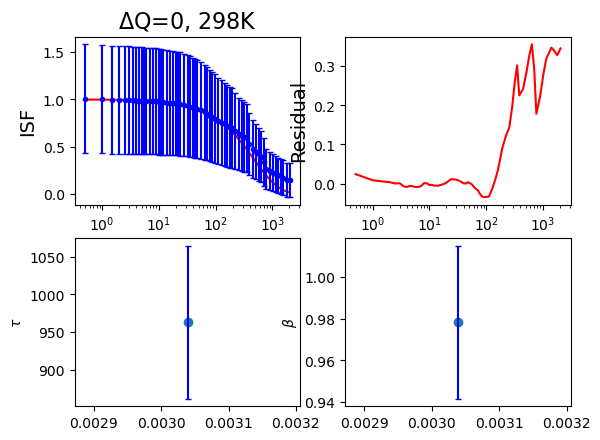

In [23]:
fig, ax = plt.subplots(2,2)
i = 0
trunc = 30

def g2_exp_pow(t,A,tt1,tt2,b,a):
    return 1+A*(np.exp(-(t/tt1)**b)+(t/tt2)**(-a))**2

def power_law(t,t0,a):
    return (t0/t)**(a)

for i in np.array([0]):
    
    if not Double_Exp:
        popt,pcov = curve_fit(g2_exp, delay[0,:-trunc],G2_result[i,:-trunc],p0=[1,1000,1])
        errors = np.sqrt(np.diag(pcov))
        res = G2_result[i,:]-g2_exp(delay[0,:],*popt)
        ax[0,0].semilogx(delay[0,:],(g2_exp(delay[0,:],*popt)-1)/popt[0],'r-',label=f'$\\tau$={popt[1]} \n $\\beta$={popt[2]}')

    if Double_Exp:
        popt,pcov = curve_fit(g2_two_tau, delay[0,:-trunc],G2_result[i,:-trunc],p0=[1,0.8,500,5000,1,1])
        errors = np.sqrt(np.diag(pcov))
        res = G2_result[i,:]-g2_two_tau(delay[0,:],*popt)
        ax[0,0].semilogx(delay[0,:],(g2_two_tau(delay[0,:],*popt)-1)/popt[0],'r-',label=f'$\\tau$={popt[1]} \n $\\beta$={popt[2]}')

    ISF = (G2_result[i,:]-1)/popt[0]
    #popt = np.array([As[i],taus[i],betas[i]])
    ax[0,0].errorbar(delay[0,:],ISF, yerr=G2_error[i,:],fmt='none',ecolor='b',capsize=2)
    ax[0,0].semilogx(delay[0,:],ISF,'b.')
    ax[0,0].set_xlabel('Delay [s]',fontsize=14)
    ax[0,0].set_ylabel('ISF',fontsize=14)
    ax[0,0].set_title('$\Delta$Q=0, 298K',fontsize=16)
    #ax[0].semilogx(delay[0,:],g2_exp_pow(delay[0,:],*popt),'r-',label=f'$\\tau$={popt[1]} \n $\\beta$={popt[2]}')
    #ax[0,0].semilogx(delay[0,:],g2_exp(delay[0,:],*popt),'r-',label=f'$\\tau$={popt[1]} \n $\\beta$={popt[2]}')
    
    #for d in np.array([1,3,9,18]):

        #ax[0,0].axvline(x=popt[1]*d, color='k', linestyle='--', linewidth=1)

    
    #ax[1].semilogx(delay[0,:],G2_result[i,:]-g2_exp(delay[0,:],*popt),'r-')
    ax[0,1].semilogx(delay[0,:],res,'r-')
    
    #pp, poo = curve_fit(power_law, delay[0,36:-1],res[36:-1],p0=[3,1])
    #ax[0,1].loglog(delay[0,27:-3],power_law(delay[0,27:-3],*pp),'b',label=f'$\\alpha$={pp[1]}\n t0={pp[0]}')
    ax[0,1].set_ylabel('Residual',fontsize=14)
    ax[0,1].set_xlabel('Delay [s]',fontsize=14)

    
    ax[1,0].scatter(dQ[i],popt[1])
    ax[1,0].errorbar(dQ[i],popt[1], yerr=errors[1],fmt='none',ecolor='b',capsize=2)
    ax[1,0].set_ylabel('$\\tau$')
    ax[1,1].scatter(dQ[i],popt[2])
    ax[1,1].errorbar(dQ[i],popt[2], yerr=errors[2],fmt='none',ecolor='b',capsize=2)
    ax[1,1].set_ylabel('$\\beta$')

## Plot All g2s

<IPython.core.display.Javascript object>


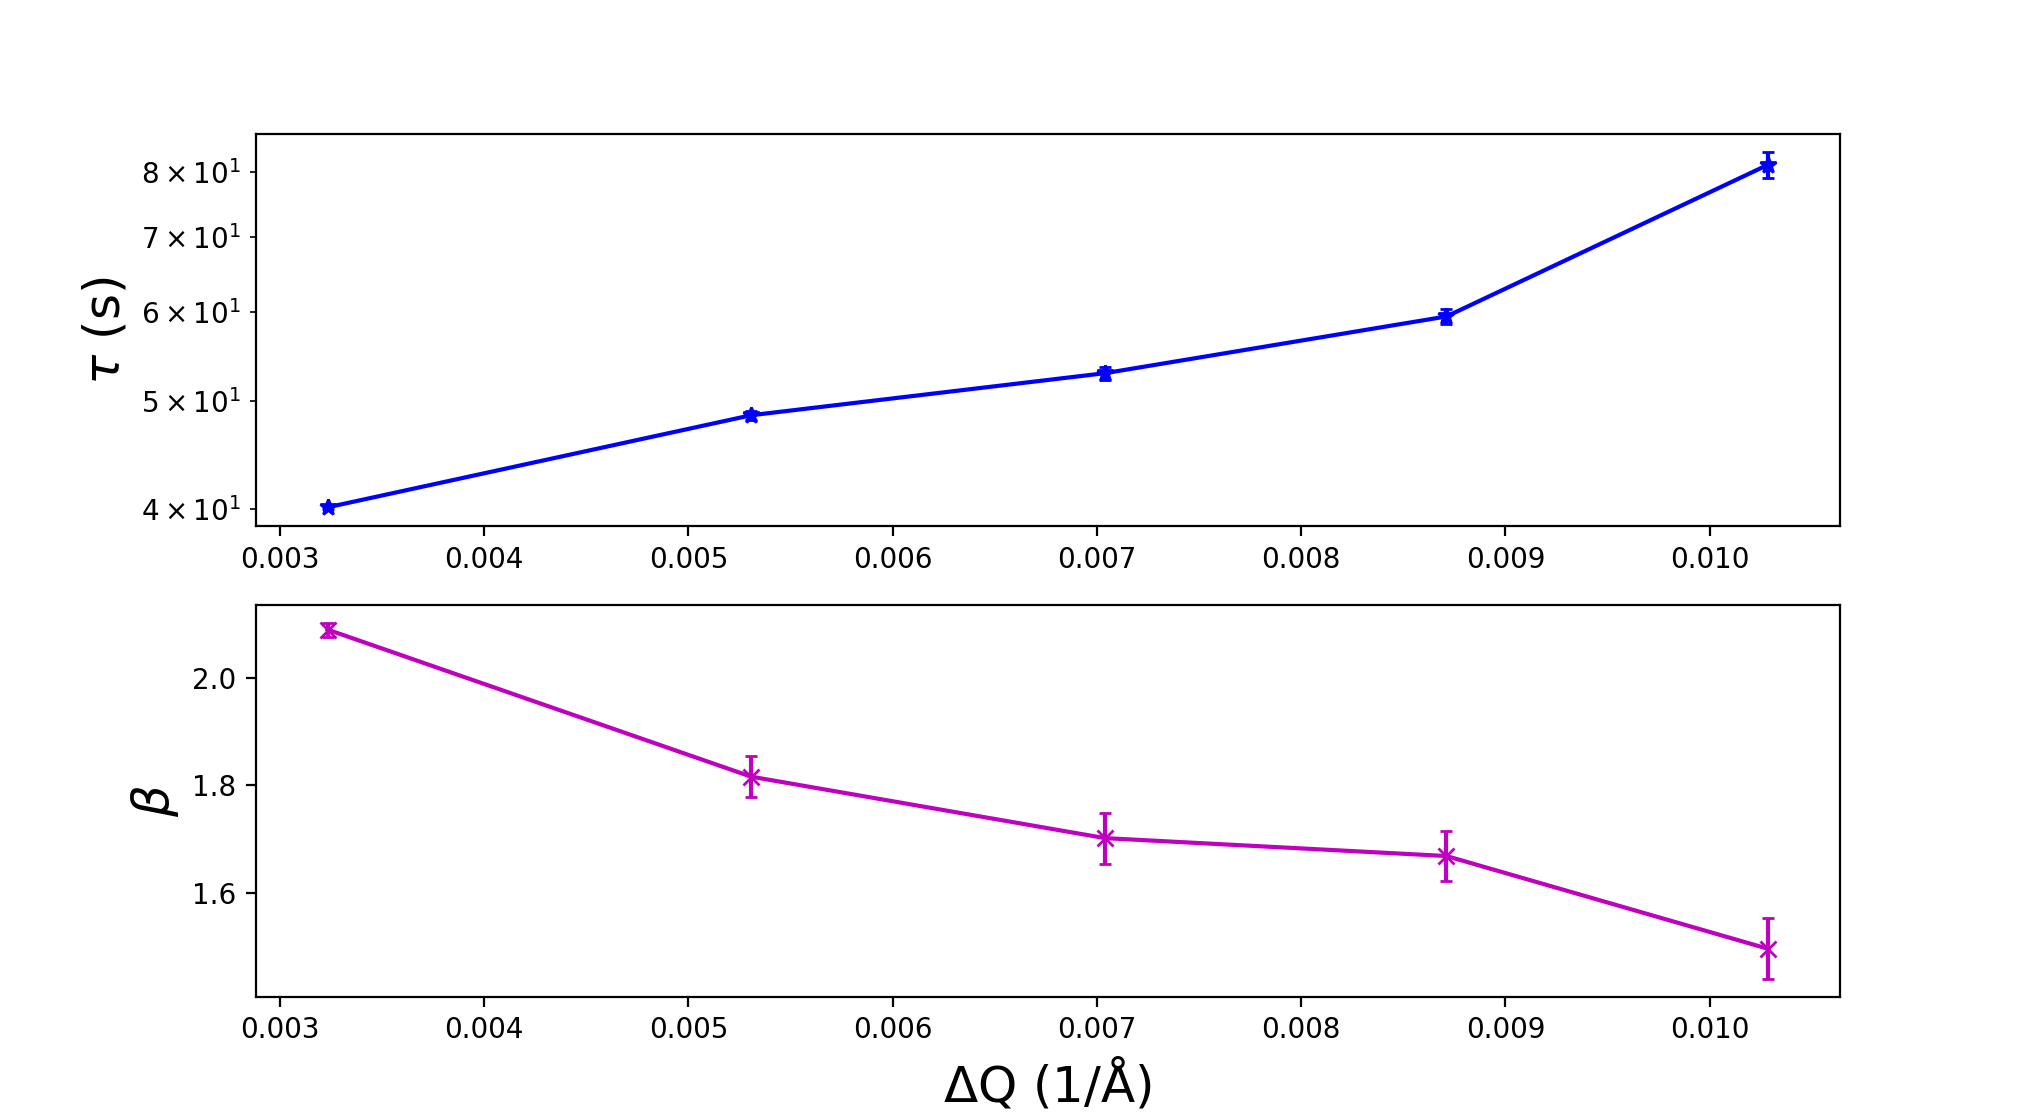

In [69]:
### UNBINNED PLOTTING ###
# Plotting 
fig, axs = plt.subplots(2,1)

# tau plot
if not Double_Exp:
    axs[0].errorbar(dQ,taus, yerr=taus_err,fmt='none',ecolor='b',capsize=2)
    axs[0].semilogy(dQ,taus,'b-*',label='$\\tau_F$')
    #axs[0].set_xlabel('$\\Delta$Q (1/Å)')
    axs[0].set_ylabel('$\\tau$ (s)',fontsize=18)
    #axs[0].legend(loc = 'center left')
    
    # beta plot
    axs[1].plot(dQ,betas,'m-x',label='$\\beta$')
    axs[1].errorbar(dQ,betas,yerr=betas_err,fmt='none',ecolor='m',capsize=2)
    axs[1].set_xlabel('$\\Delta$Q (1/Å)',fontsize=18)
    axs[1].set_ylabel('$\\beta$',fontsize=18)
    #axs[1].legend(loc = 'center right')



if Double_Exp:
    axs[0].errorbar(dQ,taus[:,0], yerr=taus_err[:,0],fmt='none',ecolor='b',capsize=2)
    axs[0].semilogy(dQ,taus[:,0],'b-*',label='$\\tau_F$')
    axs[0].errorbar(dQ,taus[:,1], yerr=taus_err[:,1],fmt='none',ecolor='r',capsize=2)
    axs[0].semilogy(dQ,taus[:,1],'r-o',label='$\\tau_S$')
    #axs[0].set_xlabel('$\\Delta$Q (1/Å)')
    axs[0].set_ylabel('$\\tau$ (s)')
    axs[0].legend(loc = 'center left')
    #axs[0].xaxis.set_visible(False)
    
    # beta plot
    axs[1].plot(dQ,betas[:,0],'m-x',label='$\\beta_F$')
    axs[1].errorbar(dQ,betas[:,0],yerr=betas_err[:,0],fmt='none',ecolor='m',capsize=2)
    axs[1].plot(dQ,betas[:,1],'g-s',label='$\\beta_S$')
    axs[1].errorbar(dQ,betas[:,1],yerr=betas_err[:,1],fmt='none',ecolor='g',capsize=2)
    axs[1].set_xlabel('$\\Delta$Q (1/Å)')
    axs[1].set_ylabel('$\\beta$')
    axs[1].legend(loc = 'center right')



"""""""""
if Double_Exp:
    # a plot
    axs2 = axs[1].twinx()
    axs2.errorbar(dQ,aas,yerr=aas_err,fmt='none',ecolor='g',capsize=2)
    axs2.plot(dQ,aas,'g-s',label='a')
    #axs[1].semilogy(dQ_sorted,betas_sorted[:,1],'r-o',label='$\\beta_2$')
    axs2.set_xlabel('$\\Delta$Q (1/Å)')
    axs2.set_ylabel('a')
    axs2.legend(loc = 'center left')
"""""""""

plt.show()


# Two-Time Correlation

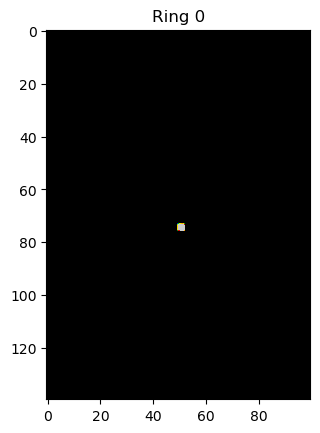

9978.0


In [40]:
M = 0

# Plot ROI
fig, ax = plt.subplots()

#fig, ax = plt.subplots()
#make_detector_movie('mask0.gif', det*masks[M,:,:]+1, np.arange(1,det.shape[0]),frameSpacing, fig, ax, frameSpacing*2,scale='log',clims = [1,10])


# Overlay the second image with a 'plasma' color scale and some transparency
ax.imshow(np.sum(det[0:1,:,:],axis=0)*masks[M,:,:]+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=500))
#ax.imshow((det[:,:,:]*masks[M,:,:])[:,:,det.shape[2]//2].T+1,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=500))
ax.set_title(f'Ring {M}')
# Display the plot
plt.show()

print(np.max(det[:,:,:]*masks[M,:,:]))

In [41]:
IMG_temp = det[:,masks[M,:,:]==1]
#IMG_temp = det[:,mask_sum>0]
IMGS_NORM = IMG_temp.reshape((IMG_temp.shape[0],IMG_temp.shape[1],1))
#IMGS_NORM = IMG_temp.reshape((650,IMG_temp.shape[1],1))


C = twotime(IMGS_NORM)#/np.size(det[:,masks[M,:,:]==1])
C_extent = [0,frameSpacing*det.shape[0],0,frameSpacing*det.shape[0]]



<function matplotlib.pyplot.show(close=None, block=None)>

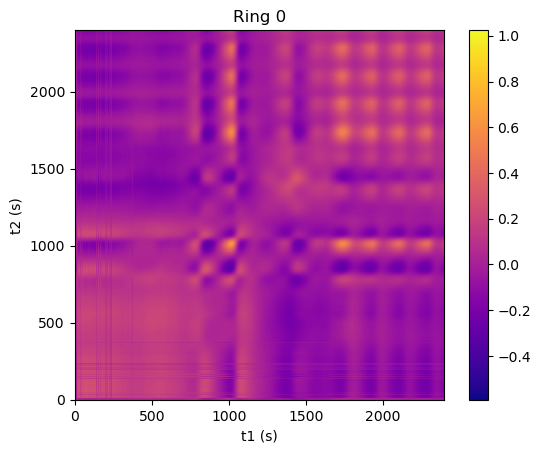

In [42]:
import matplotlib.pyplot as plt
%matplotlib inline

#C/np.size(det[:,masks[M,:,:]==1])
fig,ax = plt.subplots()
ax.set_ylabel('t2 (s)')
ax.set_xlabel('t1 (s)')
ax.set_title(f'Ring {M}')
#ax.set_title('Whole Mask')
im=ax.imshow(C,origin="lower",extent=C_extent,cmap='plasma')
fig.colorbar(im, ax=ax)

plt.show

# Waterfall

Try taking a series of line cuts: Central row/column, +2, +4, +8..

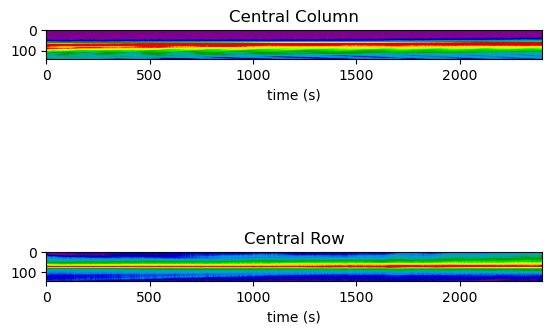

In [26]:
wfs = 1

if Geometry == "Horizontal":
    waterfall_col = np.sum(det[:,:,det.shape[2]//2-3:det.shape[2]//2+2],axis=2).T+1
    waterfall_row = np.sum(det[:,det.shape[1]//2-3:det.shape[1]//2+2,:],axis=1).T+1
if Geometry == "Vertical":
    waterfall_col = np.sum(det[:,:,det.shape[2]//2-3:det.shape[2]//2+2],axis=2).T+1
    waterfall_row = np.sum(det[:,det.shape[1]//2-3:det.shape[1]//2+2,:],axis=1).T+1


waterfall_extent = extent=[0,det.shape[0]*frameSpacing,det.shape[1],0]

fig, ax = plt.subplots(2,1)

ax[0].imshow(waterfall_col,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=waterfall_col.max()),extent=waterfall_extent)
ax[0].set_xlabel('time (s)')
ax[0].set_title('Central Column')

ax[1].imshow(waterfall_row,cmap='nipy_spectral',norm=LogNorm(vmin=1, vmax=waterfall_row.max()),extent=waterfall_extent)
ax[1].set_xlabel('time (s)')
ax[1].set_title('Central Row')

plt.subplots_adjust(wspace=0.05, hspace=0.5)


# SAVE DATA

In [33]:
results_path = work_path / Path("results")
results      = results_path / f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_ms{maskSize}_nr{numRings}ns{numSlices}_bin{binSize}_st{startTime}_tb{int(timeBatch)}_newmask{New_Mask}_tilt{Tilted_Mask}.h5'

#Check that path exists. Make a new one if it does not 
#Save as a compressed hdf5
if not os.path.exists(results_path):
    os.mkdir(results_path)
    if os.path.exists(results_path):
        print(f"Directory '{results_path}' created!")

if not os.path.exists(results):
    # Save variables to the same HDF5 file
    with h5py.File(results, 'w') as h5file:
        # Create groups
        group1 = h5file.create_group('XPCS') #Analysis results
        group2 = h5file.create_group('Parameters') #Analysis Parameters
        group3 = h5file.create_group('Stability')

        #group2 = h5file.create_group('Intensity') #Analysis results
        

        
        # Create datasets for each variable
        group1.create_dataset('det_corr', data=det_corr, compression='gzip', compression_opts=9) #G2 results

        group1.create_dataset('G2_Results', data=G2_result, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('G2_error', data=G2_error, compression='gzip', compression_opts=9) #G2 error
        group1.create_dataset('delays', data=delay, compression='gzip', compression_opts=9) #delay times, x-axis for g2
        group1.create_dataset('dQ', data=dQ, compression='gzip', compression_opts=9) #dQ
        group1.create_dataset('Qx', data=Qx, compression='gzip', compression_opts=9) #dQ
        group1.create_dataset('Qy', data=Qy, compression='gzip', compression_opts=9) #dQ
        group1.create_dataset('Qx0', data=np.array([Qx0]), compression='gzip', compression_opts=9) #dQ
        group1.create_dataset('Qy0', data=np.array([Qy0]), compression='gzip', compression_opts=9) #dQ
        group1.create_dataset('hSig', data=np.array([hSig]), compression='gzip', compression_opts=9) #dQ
        group1.create_dataset('vSig', data=np.array([vSig]), compression='gzip', compression_opts=9) #dQ

        group1.create_dataset('taus', data=taus, compression='gzip', compression_opts=9) #relaxation times
        group1.create_dataset('taus_err', data=taus_err, compression='gzip', compression_opts=9) #relaxation times errors
        group1.create_dataset('betas', data=betas, compression='gzip', compression_opts=9) #betas
        group1.create_dataset('betas_err', data=betas_err, compression='gzip', compression_opts=9) #betas error
        group1.create_dataset('As', data=As, compression='gzip', compression_opts=9) #Amplitude
        group1.create_dataset('As_err', data=As_err, compression='gzip', compression_opts=9) #Amplitude error
        group1.create_dataset('aas', data=aas, compression='gzip', compression_opts=9) #Mixture (double exp only, zeros otherwise)
        group1.create_dataset('aas_err', data=aas_err, compression='gzip', compression_opts=9) #Mixture term error
        #group1.create_dataset('AvgG2', data=avgG2, compression='gzip', compression_opts=9) #G2 results
        #group1.create_dataset('AvgG2_error', data=avgG2_err, compression='gzip', compression_opts=9) #G2 results
        #group1.create_dataset('AvgG2_fit', data=avgpopt, compression='gzip', compression_opts=9) #G2 results
        #group1.create_dataset('AvgG2_fit_error', data=avg_fit_err, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('TwoTime', data=C, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('TwoTime_extent', data=C_extent, compression='gzip', compression_opts=9) #TwoTime correlation matrix

        
        group1.create_dataset('Waterfall_Col', data=waterfall_col, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('Waterfall_Row', data=waterfall_row, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('Waterfall_extent', data=waterfall_extent, compression='gzip', compression_opts=9) #TwoTime correlation matrix
        group1.create_dataset('Mask', data=masks, compression='gzip', compression_opts=9) #Mask used
        group1.create_dataset('ringWidths', data=ringWidths, compression='gzip', compression_opts=9) #Mask used

        group1.create_dataset('frameSpacing', data=np.array([frameSpacing]), compression='gzip', compression_opts=9) #Mask used
        group1.create_dataset('Time', data=time, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('perMaskInt', data=perMaskInt, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('perPixelInt', data=perPixelInt, compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('TotalMaskInt', data=np.sum(perMaskInt,axis=0), compression='gzip', compression_opts=9) #G2 results
        group1.create_dataset('TotalPixelInt', data=np.mean(perPixelInt,axis=0), compression='gzip', compression_opts=9) #G2 results
        
        group2.create_dataset('binSize', data=np.array([binSize]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('timeBatch', data=np.array([timeBatch]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('startTime', data=np.array([startTime]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('stability', data=np.array([stability]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('Detrend', data=np.array([Detrend]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('newMask', data=np.array([New_Mask]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('tiltedMask', data=np.array([Tilted_Mask]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('maskSize', data=np.array([maskSize]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('numRings', data=np.array([numRings]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('numSlices', data=np.array([numSlices]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('tol', data=np.array([tol]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('res', data=np.array([res]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('a', data=np.array([a]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('tt1', data=np.array([tt1]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('tt2', data=np.array([tt2]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('b1', data=np.array([b1]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('b2', data=np.array([b2]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('trunc', data=np.array([trunc]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('tilt', data=np.array([tilt]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('mx0', data=np.array([int(mx0)]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('my0', data=np.array([int(my0)]), compression='gzip', compression_opts=9) #G2 results
        group2.create_dataset('dt', data=dt, compression='gzip', compression_opts=9) #G2 results

        
            
        group3.create_dataset('POPTX', data=POPTX, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('POPTY', data=POPTY, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('Mux', data=Mux, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('Muy', data=Muy, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('SigX', data=SigX, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('SigY', data=SigY, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('freqs', data=freqs, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('ftMux', data=ftMux, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('ftMuy', data=ftMuy, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('ftSigX', data=ftSigX, compression='gzip', compression_opts=9) #G2 results
        group3.create_dataset('ftSigY', data=ftSigY, compression='gzip', compression_opts=9) #G2 results

            
            
    print(f"File '{f'particle{Particle}_temp{Temperature}K_scan{Scan}_crop{Xv}x{Xh}_ms{maskSize}_nr{numRings}ns{numSlices}_bin{binSize}_st{startTime}_tb{int(timeBatch)}_newmask{New_Mask}_tilt{Tilted_Mask}.h5'
}' saved!")

File 'particle2_temp350.0K_scan868_crop5x5_ms1.0_nr5ns1_bin1_st0_tb2700_newmaskTrue_tiltTrue.h5' saved!
